# Advanced Trading Strategy

1. Define Momentum Conditions:

* Price Movement: Use Rate of Change (ROC) or Moving Average crossovers as your momentum entry signal. (Positive ROC suggests bullish momentum, and vice versa.)

* Volatility Filter: Use ATR to confirm strong volatility (momentum). You don’t want to trade in low volatility periods. (ATR rising suggests increasing volatility and strong price movement.)

* Directional Confirmation: Use DMI or MACD to confirm that momentum is strong in one direction. (+DI > -DI indicates an ongoing bullish trend (and vice versa for bearish momentum).)

2. Risk Management:

* Use a fixed percentage of your capital per trade (e.g., 1–2% per trade).

* Implement a stop loss based on volatility (using ATR or a fixed percentage).

* Implement a take-profit level or trailing stop to capture the trend’s full potential.

3. Position Sizing:

* Risk-based sizing: The position size should scale with volatility. Use ATR to determine how large a position to take based on the current volatility.

For example, larger ATR means higher risk, so you reduce position size.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import os, json, datetime
import talib
import matplotlib.pyplot as plt
from utils.read_prices import read_parquet

In [2]:
data = read_parquet()

data.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
Date,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615


In [3]:
## creates momentum signal like we did in the momentum strategy notebook
data['momentum_signal'] = np.sign(data['log_returns'].rolling(2).mean())
# data["momentum_strat"] = data["momentum_signal"].shift(1) * data["log_returns"]

In [4]:
## number of signals that this strategy encounters
data["momentum_signal"].value_counts(), data["momentum_signal"].value_counts().sum()

(momentum_signal
  1.0    1039
 -1.0     785
 Name: count, dtype: int64,
 np.int64(1824))

In [5]:
## creates indicators to lessen the number of times we enter/exit the market

data['atr'] = talib.ATR(data['High'], data['Low'], data['Close'])
data['di+'] = talib.PLUS_DI(data['High'], data['Low'], data['Close'])
data['di-'] = talib.MINUS_DI(data['High'], data['Low'], data['Close'])
data["adx"] = talib.ADX(data["High"], data["Low"], data["Close"]) 

In [6]:
## creates conditions where the di+/- are less than/greater than one another
## as well as the atr compared to its mean

# data["signal"] = np.where(data['momentum_signal'] == 0, 1, -1)
data["momentum_signal"] = np.where(data['di+'] > data['di-'], 1, -1)
data["momentum_signal"] = np.where(data['atr'] < data['atr'].mean(), 1, -1)
data["momentum_signal"] = np.where(data["adx"] > 20, 1, -1)

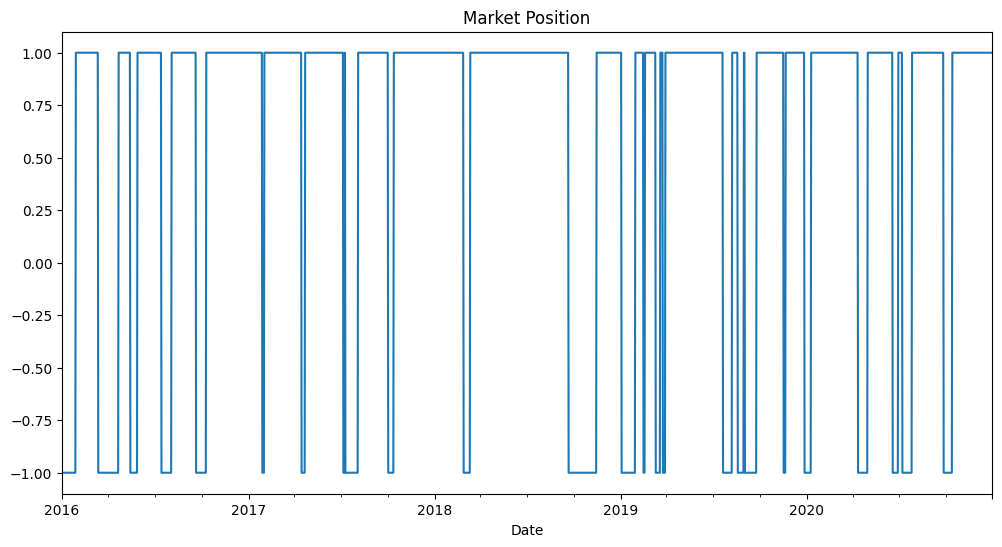

In [7]:
data['momentum_signal'].plot(ylim=[-1.1, 1.1],
                    title="Market Position",
                    figsize=(12,6))
plt.show()

In [8]:
## we see that the conditions has dropped the entrance signals close to 400
## and the sell signals actually rose by 400

data["momentum_signal"].value_counts(),  data["momentum_signal"].value_counts().sum()

(momentum_signal
  1    1407
 -1     419
 Name: count, dtype: int64,
 np.int64(1826))

In [9]:
data["momentum_strat"] = data["momentum_signal"].shift(1) * data["log_returns"]

In [10]:
data["action"] = data["momentum_signal"].diff()

In [11]:
data["action"].value_counts()

action
 0.0    1776
 2.0      25
-2.0      24
Name: count, dtype: int64

In [12]:
adv_buy_signals = data[(data['momentum_signal'] > 0) & (data['di+'] > data['di-']) & (data["atr"] < data['atr'].mean())][data.action == 2]

/var/folders/ly/yp55phj14sggk71834drw0d80000gn/T/ipykernel_91898/3544989945.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  adv_buy_signals = data[(data['momentum_signal'] > 0) & (data['di+'] > data['di-']) & (data["atr"] < data['atr'].mean())][data.action == 2]


In [13]:
adv_buy_signals

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,momentum_signal,atr,di+,di-,adx,momentum_strat,action
Date,,,,,,,,,,,,,,,
2016-04-21,449.424988,450.548004,440.951996,441.415985,68204704,0.37,1.018206,0.018042,1,5.232257,48.078270,12.889756,21.993278,-0.018042,2.0
2016-05-28,530.039978,533.473022,472.699005,473.028992,181199008,0.37,1.119494,0.112877,1,10.872553,62.943356,11.713417,22.702921,-0.112877,2.0
2016-10-10,618.994019,621.317993,616.197021,616.822021,67481104,0.40,1.003635,0.003629,1,4.672210,34.384905,15.905890,20.646037,-0.003629,2.0
2017-02-01,989.023010,989.114014,970.742004,970.940979,150110000,0.66,1.019188,0.019006,1,31.402526,38.509625,18.615730,20.806403,-0.019006,2.0
2017-04-22,1231.709961,1235.560059,1208.469971,1222.709961,249320000,0.91,1.007905,0.007874,1,31.951200,28.431034,17.142231,20.234862,-0.007874,2.0
2017-07-09,2518.439941,2635.489990,2517.590088,2572.610107,527856000,1.16,0.979427,-0.020788,1,146.398230,29.421817,17.793550,20.177578,0.020788,2.0
2017-08-04,2895.889893,2899.330078,2743.719971,2806.929932,1002120000,1.16,1.032502,0.031985,1,175.919770,30.592336,16.317889,20.408049,-0.031985,2.0
2017-10-13,5647.209961,5840.299805,5436.850098,5464.160156,3615480064,1.16,1.036773,0.036113,1,250.035725,49.544174,12.737703,22.504110,-0.036113,2.0
2019-02-18,3915.714355,3936.665039,3669.982422,3671.369873,9908216640,2.40,1.065838,0.063761,1,85.693789,40.763307,13.751871,21.239024,-0.063761,2.0


In [14]:
adv_sell_signal = data[(data['momentum_signal'] < 0) & (data['di+'] < data['di-']) & (data['atr'] > data["atr"].mean())][data.action == -2]

/var/folders/ly/yp55phj14sggk71834drw0d80000gn/T/ipykernel_91898/2391735792.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  adv_sell_signal = data[(data['momentum_signal'] < 0) & (data['di+'] < data['di-']) & (data['atr'] > data["atr"].mean())][data.action == -2]


In [15]:
adv_signals_df = pd.concat([adv_buy_signals, adv_sell_signal])
adv_signals_df.head(10)

adv_signals_df.sort_index(ascending=True)

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,momentum_signal,atr,di+,di-,adx,momentum_strat,action
Date,,,,,,,,,,,,,,,
2016-04-21,449.424988,450.548004,440.951996,441.415985,68204704,0.37,1.018206,0.018042,1,5.232257,48.078270,12.889756,21.993278,-0.018042,2.0
2016-05-28,530.039978,533.473022,472.699005,473.028992,181199008,0.37,1.119494,0.112877,1,10.872553,62.943356,11.713417,22.702921,-0.112877,2.0
2016-10-10,618.994019,621.317993,616.197021,616.822021,67481104,0.40,1.003635,0.003629,1,4.672210,34.384905,15.905890,20.646037,-0.003629,2.0
2017-02-01,989.023010,989.114014,970.742004,970.940979,150110000,0.66,1.019188,0.019006,1,31.402526,38.509625,18.615730,20.806403,-0.019006,2.0
2017-04-22,1231.709961,1235.560059,1208.469971,1222.709961,249320000,0.91,1.007905,0.007874,1,31.951200,28.431034,17.142231,20.234862,-0.007874,2.0
2017-07-09,2518.439941,2635.489990,2517.590088,2572.610107,527856000,1.16,0.979427,-0.020788,1,146.398230,29.421817,17.793550,20.177578,0.020788,2.0
2017-08-04,2895.889893,2899.330078,2743.719971,2806.929932,1002120000,1.16,1.032502,0.031985,1,175.919770,30.592336,16.317889,20.408049,-0.031985,2.0
2017-10-13,5647.209961,5840.299805,5436.850098,5464.160156,3615480064,1.16,1.036773,0.036113,1,250.035725,49.544174,12.737703,22.504110,-0.036113,2.0
2019-02-18,3915.714355,3936.665039,3669.982422,3671.369873,9908216640,2.40,1.065838,0.063761,1,85.693789,40.763307,13.751871,21.239024,-0.063761,2.0


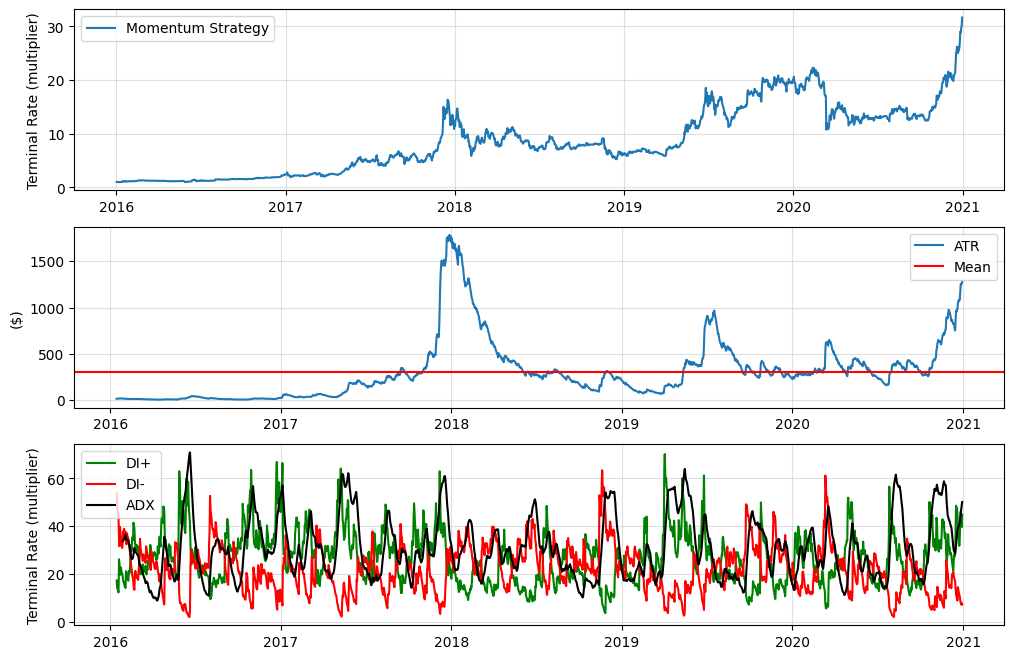

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3,1, figsize=(12,8))

# ax[0].plot(np.exp(data['log_returns'].cumsum()), label='Cumulative Returns')
ax[0].plot(np.exp(data["momentum_strat"].cumsum()), label="Momentum Strategy")
ax[0].grid(alpha=.4)
ax[0].set_ylabel('Terminal Rate (multiplier)')
ax[0].legend()

ax[1].plot(data["atr"], label='ATR')
ax[1].axhline(data["atr"].mean(), label='Mean', c='r')
ax[1].set_ylabel('($)')
ax[1].grid(alpha=.4)
ax[1].legend()

ax[2].plot(data['di+'], label='DI+', color='g')
ax[2].plot(data['di-'], label='DI-', color='r')
ax[2].plot(data["adx"], label="ADX", color='black')
ax[2].grid(alpha=.4),
ax[2].set_ylabel('Terminal Rate (multiplier)')
ax[2].legend()

plt.show()

## Preprocessing

To see how the strategy is making decisions by at the same scale, we will need to preprocess the indicators; scaling them down to a number between 0 and 1.

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
scaler = MinMaxScaler()

In [18]:
df = data.copy()
adv_buy_signals_df = adv_buy_signals.copy()
adv_sell_signals_df = adv_sell_signal.copy()

df = df[["Close", "momentum_strat", "atr", "di+", "di-", "adx", "momentum_signal"]]

In [19]:
df["momentum_strat"] = np.exp(df["momentum_strat"].cumsum())
adv_buy_signals_df["momentum_strat"] = np.exp(adv_buy_signals_df["momentum_strat"])
adv_sell_signals_df["momentum_strat"] = np.exp(adv_sell_signals_df["momentum_strat"])

In [20]:
df.head()

,Close,momentum_strat,atr,di+,di-,adx,momentum_signal
Date,,,,,,,
2016-01-01,434.334015,NaN,NaN,NaN,NaN,NaN,-1
2016-01-02,433.437988,1.002067,NaN,NaN,NaN,NaN,-1
2016-01-03,430.010986,1.010053,NaN,NaN,NaN,NaN,-1
2016-01-04,433.091003,1.002870,NaN,NaN,NaN,NaN,-1
2016-01-05,431.959991,1.005496,NaN,NaN,NaN,NaN,-1


In [21]:
scaled_df = scaler.fit_transform(df)
scaled_adv_buy_signals = scaler.fit_transform(adv_buy_signals_df)
scaled_adv_sell_signals = scaler.fit_transform(adv_sell_signals_df)

In [22]:
scaled_df = pd.DataFrame(scaled_df,
             columns=df.columns,
             index=df.index)

scaled_adv_buy_signals = pd.DataFrame(
    scaled_adv_buy_signals,
    columns=adv_buy_signals_df.columns,
    index=adv_buy_signals_df.index
)

scaled_adv_sell_signals = pd.DataFrame(
    scaled_adv_sell_signals,
    columns=adv_sell_signals_df.columns,
    index=adv_sell_signals_df.index
)

In [23]:
scaled_adv_sell_signals

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns,momentum_signal,atr,di+,di-,adx,momentum_strat,action
Date,,,,,,,,,,,,,,,
2019-07-21,0.921876,0.981412,0.928384,1.000000,0.035448,1.000000,0.000000,0.000000,0.0,1.000000,0.650223,0.000000,0.000000,0.000000,0.0
2019-08-19,1.000000,1.000000,0.908681,0.890732,0.000000,0.881356,1.000000,1.000000,0.0,0.401768,0.803503,0.670192,0.699612,1.000000,0.0
2020-04-11,0.000000,0.000000,0.000000,0.000000,0.492753,0.000000,0.207460,0.213242,0.0,0.080569,1.000000,1.000000,0.383484,0.207460,0.0
2020-09-26,0.959248,0.964147,1.000000,0.979040,1.000000,0.016949,0.297367,0.304682,0.0,0.000000,0.000000,0.025188,1.000000,0.297367,0.0


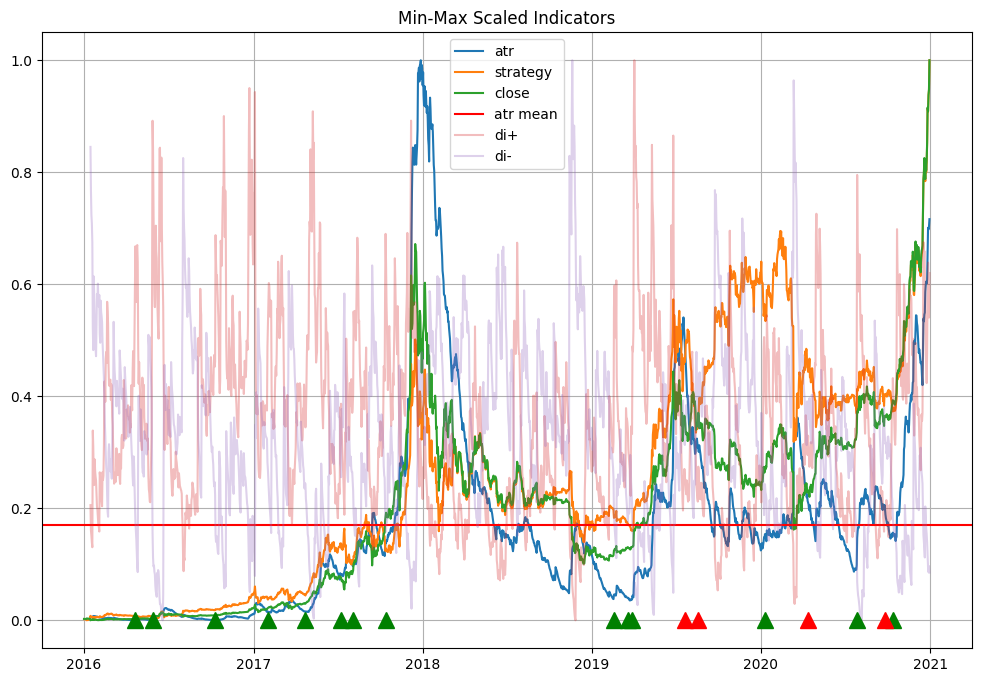

In [24]:
fig, ax = plt.subplots(1,1, figsize=(12,8))

ax.plot(scaled_df[["atr", "momentum_strat", "Close"]], label=["atr", "strategy", "close"])
# ax.plot(adv_buy_signals_df["momentum_strat"], label="Buy Signal")
# ax.plot(adv_sell_signals_df["momentum_strat"], label="Buy Signal")
ax.axhline(scaled_df["atr"].mean(), label="atr mean", color='r')
ax.plot(scaled_df[["di+", "di-"]], alpha=.3, label=["di+", "di-"])
ax.plot(
    scaled_adv_buy_signals.index,
    scaled_adv_buy_signals["momentum_signal"],
    '^',
    color = 'g',
    markersize = 12)
ax.plot(
    scaled_adv_sell_signals.index,
    scaled_adv_sell_signals["momentum_signal"],
    '^',
    color = 'r',
    markersize = 12)

plt.legend()
plt.grid(.4)
plt.title("Min-Max Scaled Indicators")
plt.show()

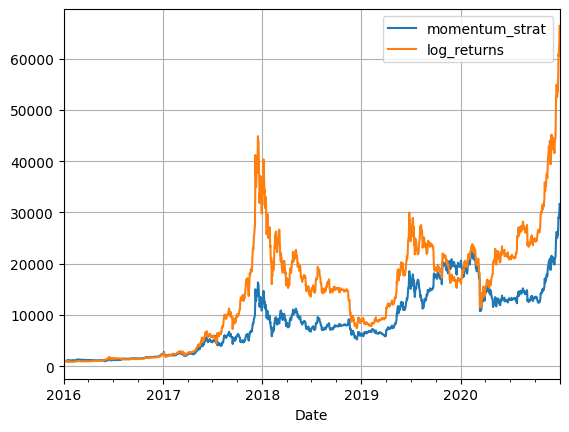

In [25]:
init_investment = 1000

cum_returns = np.exp(data[["momentum_strat", "log_returns"]].cumsum())*init_investment
cum_returns.plot(kind="line")
plt.grid(.4)
plt.show()

In [26]:
from utils.metrics import Metrics as m

print(f"Terminal Return of advanced strategy: {m.terminal_return(data['momentum_strat'])*100:.2f}%")
print(f"Annualized Returns of advanced strategy: {m.annualized_return(np.exp(data['momentum_strat']))*100:.2f}%")

Terminal Return of advanced strategy: 3066.67%
Annualized Returns of advanced strategy: 99.51%


## Backtest

In [27]:
from utils.event_backtest import EventBacktestMomentum
from utils.backtest import *

In [33]:
mombt_3 = EventBacktestMomentum(
    'BTC-USD',
    '2021-01-01',
    '2025-12-31',
    trans_cost=0.00,
    amount=1000
    )
creturns, cstrat = mombt_3.strategy(momentum=2)
creturns, cstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(2256.6), np.float64(1146.76))

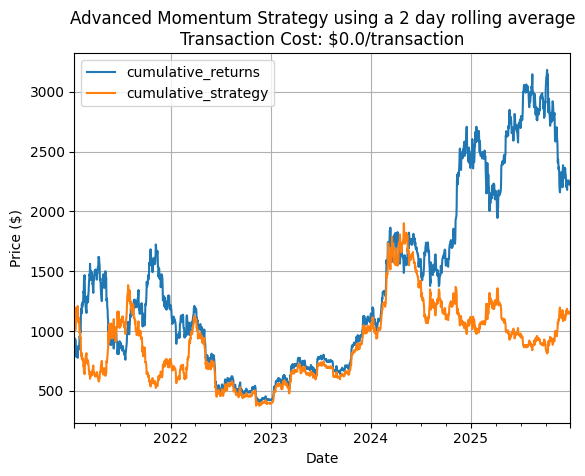

In [34]:
mombt_3.plot_strategy()

In [35]:
mombt_3.get_terminal_return(), mombt_3.get_drawdown()

((1.26, 0.15), (np.float64(-1.0107508721993381), np.float64(-1.0)))

In [30]:
mombt_3_trans = EventBacktestMomentum(
    'BTC-USD',
    '2021-01-01',
    '2025-12-31',
    trans_cost=0.36,
    amount=5000
    )
creturns_trans, cstrat_trans = mombt_3_trans.strategy(momentum=2)
creturns_trans, cstrat_trans

[*********************100%***********************]  1 of 1 completed


(np.float64(11283.0), np.float64(5722.24))

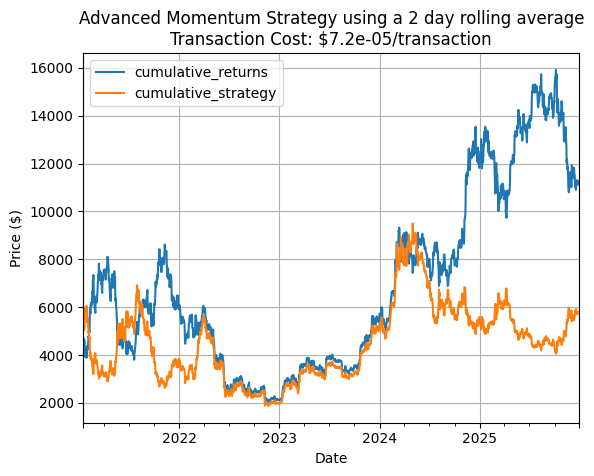

In [31]:
mombt_3_trans.plot_strategy()